In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2-xl").to(device)

tokenizer.pad_token = tokenizer.eos_token

model.eval();

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

# Implant hooks to QKV activations

In [4]:
num_layers = model.config.n_layer
num_embed = model.config.n_embd

In [5]:
# Remove old hooks if they exist
if "hook_handles" in globals() and len(hook_handles) > 0:
    for h in hook_handles:
        h.remove()

hook_handles = []
activations = {}


for layeri in range(num_layers):
    hook_name = f"attn_{layeri}_qkv"
    activations[hook_name] = None

    handle = model.transformer.h[layeri].attn.c_attn.register_forward_hook(
        lambda module, inp, out, hook_name=hook_name:
            activations.__setitem__(hook_name, out.detach())
    )

    hook_handles.append(handle)

# Select sentences

In [6]:
# generated by Claude.ai
sentences = [
    "I saw her at the market.",
    "She gave her the book.",
    "They asked her for advice.",
    "We invited her to dinner.",
    "The dog followed her home.",
    "They asked her to join.",
    "He saw her at the park yesterday.",
    "Did you give her your address?",
    "I haven't seen her in ages.",
    "I told her the truth.",
    "They congratulated her on his success.",
    "She recognized her immediately.",
    "The teacher praised her for his work.",
    "I met her last summer.",
    "The child hugged her tightly.",
    "They warned her about the danger.",
    "She drove her to the airport.",
    "We waited for her for hours.",
    "The cat scratched her accidentally.",
    "They surprised her with a gift.",
    "She called her on the phone.",
    "The jury found her not guilty.",
    "I remembered her from school.",
    "They elected her as president.",
    "She forgave her for his mistake.",
    "The police questioned her yesterday.",
    "I helped her with his homework.",
    "They spotted her in the crowd.",
    "She visited her in the hospital.",
    "The manager promoted her last week.",
    "I trusted her completely.",
    "They respected her for his honesty.",
    "She taught her how to swim.",
    "The bird attacked her suddenly.",
    "I greeted her warmly.",
    "They supported her through difficult times.",
    "She ignored her at the party.",
    "The judge sentenced her to community service.",
    "I photographed her during the event.",
    "They believed her despite the evidence.",
    "She surprised her on his birthday.",
    "The guard stopped her at the entrance.",
    "I missed her terribly.",
    "They watched her leave the building.",
    "She accompanied her to the concert.",
    "The crowd cheered her enthusiastically.",
    "I described her to the police.",
    "They thanked her for his help.",
    "She admired her for his courage.",
    "The committee nominated her for the award.",
    "I married her last spring.",
    "They informed her about the changes.",
    "She introduced her to the parents.",
    "The author based the character on her."
]

target_token = tokenizer.encode(' her')[0]
print(f'There are {len(sentences)} sentences.')
print(f'The target token is {target_token}.')

There are 54 sentences.
The target token is 607.


# Forward pass sentectes through the model

In [7]:
tokens = tokenizer(sentences, padding=True, return_tensors='pt').to(device)

with torch.no_grad():
  model(**tokens)

# Get activations from target and non-target tokens

In [8]:
target_id = tokenizer.encode(' her')[0]

input_ids = tokens['input_ids']
attention_mask = tokens['attention_mask'].bool()

is_target = (input_ids == target_id) & attention_mask
is_not_target = (~is_target) & attention_mask

eos_id = tokenizer.eos_token_id
is_not_eos = is_not_target & (input_ids != eos_id)

acts_qkv = [activations[f'attn_{i}_qkv'] for i in range(num_layers)]

activations_target = [a[is_target] for a in acts_qkv]
activations_non_target = [a[is_not_target] for a in acts_qkv]

In [9]:
print("acts_qkv[0].shape:", acts_qkv[0].shape)      # should be [B,S,3*num_embed]
print("num non-target positions:", is_not_target.sum().item())
print("layer0 non-target shape:", activations_non_target[0].shape)

acts_qkv[0].shape: torch.Size([54, 8, 4800])
num non-target positions: 310
layer0 non-target shape: torch.Size([310, 4800])


# Create matrix mask to isolate Q,K,V interactions

In [10]:
# unique values for each layer type
qLoc = 1
kLoc = 2
vLoc = 3

# a vector mask
vectorMask = np.concatenate( (np.full(num_embed,1),np.full(num_embed,2),np.full(num_embed,3)) )

# outer product to create a matrix with unique values for each interaction
matrixMask = vectorMask[:,None] @ vectorMask[None,:]
matrixMask = np.triu(matrixMask,1)

# Function to create target and non-target activations in each layer

In [35]:
def get_QKV_activations(layer_num):

  # Initialize
  acts_target = np.zeros((len(sentences),num_embed*3))
  acts_non_target = np.zeros((len(sentences),num_embed*3))

  # loop over sentences
  for senti in range(len(sentences)):

    # find the index of the target token
    if target_token not in tokens['input_ids'][senti].tolist(): continue

    target_idx = tokens['input_ids'][senti].tolist().index(target_token)

    # Get activation for the token
    acts_target[senti] = acts_qkv[layer_num][senti,target_idx].cpu().numpy()

    # Get activation for non-target token
    acts_non_target[senti] = acts_qkv[layer_num][senti,target_idx-1].cpu().numpy()

    #
  return acts_target, acts_non_target



In [38]:
# same num_bins for all histograms
edges = np.linspace(-1,1,101)
num_bins = len(edges) - 1

# lots of initializations
yQQ_trg = np.zeros((num_layers,num_bins))
yKK_trg = np.zeros((num_layers,num_bins))
yVV_trg = np.zeros((num_layers,num_bins))
yQQ_non = np.zeros((num_layers,num_bins))
yKK_non = np.zeros((num_layers,num_bins))
yVV_non = np.zeros((num_layers,num_bins))

yQK_trg = np.zeros((num_layers,num_bins))
yQV_trg = np.zeros((num_layers,num_bins))
yKV_trg = np.zeros((num_layers,num_bins))
yQK_non = np.zeros((num_layers,num_bins))
yQV_non = np.zeros((num_layers,num_bins))
yKV_non = np.zeros((num_layers,num_bins))

all_vars = np.zeros((2,num_layers,3))
all_mean = np.zeros((2,num_layers,3))



for layeri in range(num_layers):

  ### get activations from this layer
  actsAll_trg,actsAll_non = get_QKV_activations(layeri)


  ### get variances
  vars = actsAll_trg.var(axis=0)
  all_vars[0,layeri,0] = np.mean(vars[:num_embed])
  all_vars[0,layeri,1] = np.mean(vars[num_embed:num_embed*2])
  all_vars[0,layeri,2] = np.mean(vars[num_embed*2:])

  vars = actsAll_non.var(axis=0)
  all_vars[1,layeri,0] = np.mean(vars[:num_embed])
  all_vars[1,layeri,1] = np.mean(vars[num_embed:num_embed*2])
  all_vars[1,layeri,2] = np.mean(vars[num_embed*2:])


  ### get means
  meenz = actsAll_trg.mean(axis=0)
  all_mean[0,layeri,0] = np.mean(meenz[:num_embed])
  all_mean[0,layeri,1] = np.mean(meenz[num_embed:num_embed*2])
  all_mean[0,layeri,2] = np.mean(meenz[num_embed*2:])

  meenz = actsAll_non.var(axis=0)
  all_mean[1,layeri,0] = np.mean(meenz[:num_embed])
  all_mean[1,layeri,1] = np.mean(meenz[num_embed:num_embed*2])
  all_mean[1,layeri,2] = np.mean(meenz[num_embed*2:])



  ### calculate cosine similarity
  # TARGET
  actsAllNorm = actsAll_trg / np.linalg.norm(actsAll_trg,axis=0,keepdims=True)
  cossim_trg = actsAllNorm.T @ actsAllNorm

  # NON-TARGET
  actsAllNorm = actsAll_non / np.linalg.norm(actsAll_non,axis=0,keepdims=True)
  cossim_non = actsAllNorm.T @ actsAllNorm



  ### Extract unique similarities
  # TARGET within
  QQcs_trg = cossim_trg[matrixMask==qLoc*qLoc]
  KKcs_trg = cossim_trg[matrixMask==kLoc*kLoc]
  VVcs_trg = cossim_trg[matrixMask==vLoc*vLoc]

  # cross-terms
  QKcs_trg = cossim_trg[matrixMask==qLoc*kLoc]
  QVcs_trg = cossim_trg[matrixMask==qLoc*vLoc]
  KVcs_trg = cossim_trg[matrixMask==kLoc*vLoc]

  # NON-TARGET within
  QQcs_non = cossim_non[matrixMask==qLoc*qLoc]
  KKcs_non = cossim_non[matrixMask==kLoc*kLoc]
  VVcs_non = cossim_non[matrixMask==vLoc*vLoc]

  # cross-terms
  QKcs_non = cossim_non[matrixMask==qLoc*kLoc]
  QVcs_non = cossim_non[matrixMask==qLoc*vLoc]
  KVcs_non = cossim_non[matrixMask==kLoc*vLoc]



  ### Generate histograms for target and non-target

  ## TARGET
  # within-matrix histograms
  yQQ_trg[layeri,:],_ = np.histogram(QQcs_trg,bins=edges)
  yKK_trg[layeri,:],_ = np.histogram(KKcs_trg,bins=edges)
  yVV_trg[layeri,:],_ = np.histogram(VVcs_trg,bins=edges)

  # and between-matrix
  yQK_trg[layeri,:],_ = np.histogram(QKcs_trg,bins=edges)
  yQV_trg[layeri,:],_ = np.histogram(QVcs_trg,bins=edges)
  yKV_trg[layeri,:],_ = np.histogram(KVcs_trg,bins=edges)


  ## NON-TARGET
  # within-matrix histograms
  yQQ_non[layeri,:],_ = np.histogram(QQcs_non,bins=edges)
  yKK_non[layeri,:],_ = np.histogram(KKcs_non,bins=edges)
  yVV_non[layeri,:],_ = np.histogram(VVcs_non,bins=edges)

  # and between-matrix
  yQK_non[layeri,:],_ = np.histogram(QKcs_non,bins=edges)
  yQV_non[layeri,:],_ = np.histogram(QVcs_non,bins=edges)
  yKV_non[layeri,:],_ = np.histogram(KVcs_non,bins=edges)


# Visualize cosine-similarity histograms

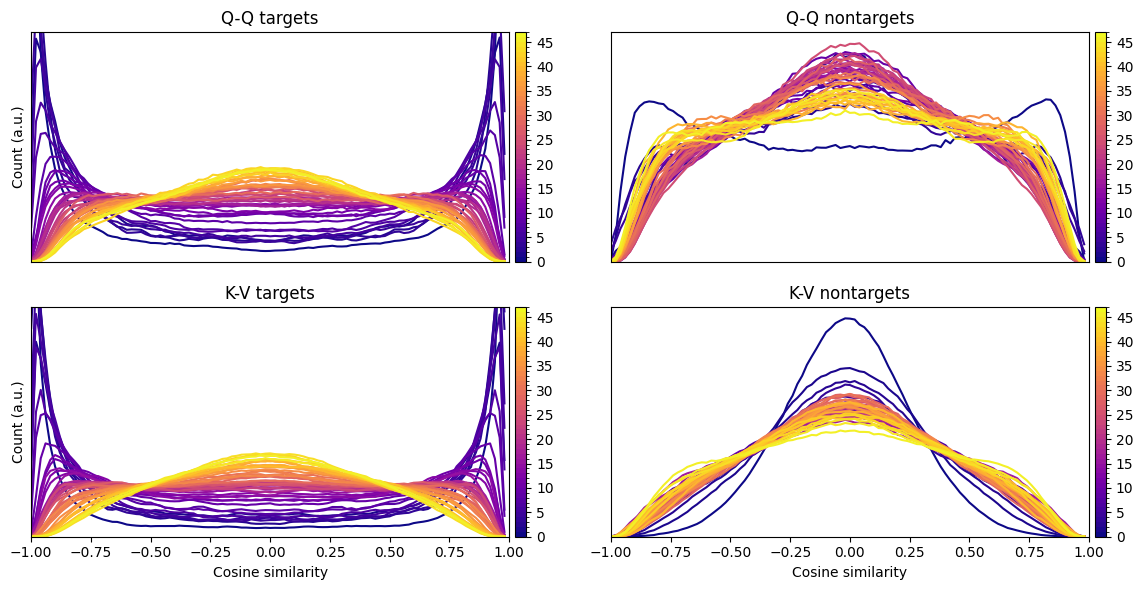

In [40]:
fig,axs = plt.subplots(2,2,figsize=(12,6))


for layeri in range(num_layers):

  #### plotting
  # QQ targets
  axs[0,0].plot(edges[:-1],yQQ_trg[layeri,:],color=mpl.cm.plasma(layeri/num_layers))
  axs[0,0].set(xlim=edges[[0,-1]],xticks=[],yticks=[],ylabel='Count (a.u.)',title='Q-Q targets')


  # QQ nontargets
  axs[0,1].plot(edges[:-1],yQQ_non[layeri,:],color=mpl.cm.plasma(layeri/num_layers))
  axs[0,1].set(xlim=edges[[0,-1]],xticks=[],yticks=[],title='Q-Q nontargets')

  # KV targets
  axs[1,0].plot(edges[:-1],yKV_trg[layeri,:],color=mpl.cm.plasma(layeri/num_layers))
  axs[1,0].set(xlim=edges[[0,-1]],xlabel='Cosine similarity',ylabel='Count (a.u.)',yticks=[],title='K-V targets')

  # KV nontargets
  axs[1,1].plot(edges[:-1],yKV_non[layeri,:],color=mpl.cm.plasma(layeri/num_layers))
  axs[1,1].set(xlim=edges[[0,-1]],xlabel='Cosine similarity',yticks=[],title='K-V nontargets')


# manually adjust the y-lims
axs[0,0].set(ylim=[0,axs[0,0].get_ylim()[1]/4])
axs[1,0].set(ylim=[0,axs[1,0].get_ylim()[1]/4])
axs[0,1].set(ylim=[0,None])
axs[1,1].set(ylim=[0,None])

# colorbar for line color (layer number)
cmap = mpl.colormaps['plasma']
norm = mpl.colors.BoundaryNorm(np.arange(num_layers), cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
for a in axs.flatten(): cbar = fig.colorbar(sm, ax=a, pad=.01)


# finalize the plot
plt.tight_layout()
plt.show()

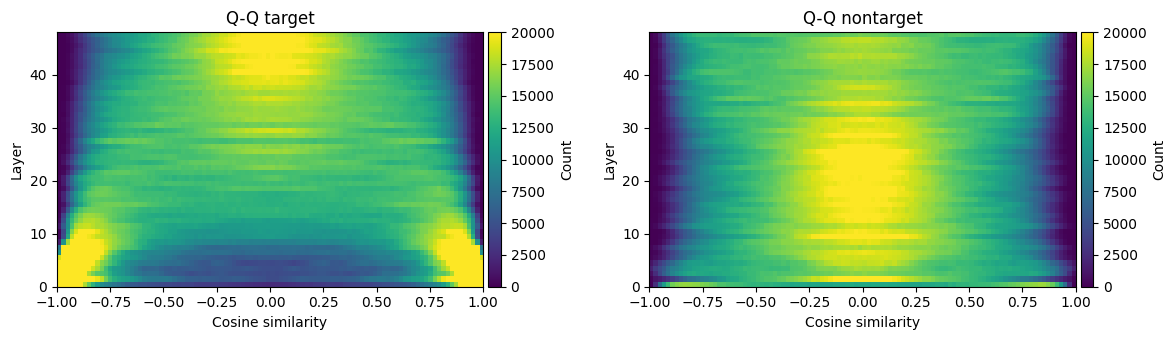

In [41]:
fig,axs = plt.subplots(1,2,figsize=(12,3.5))

h = axs[0].imshow(yQQ_trg,vmin=0,vmax=20000,origin='lower',aspect='auto',
              extent=[edges[0],edges[-1],0,model.config.n_layer])
axs[0].set(xlabel='Cosine similarity',ylabel='Layer',title='Q-Q target')
fig.colorbar(h,ax=axs[0],pad=.01,label='Count')


h = axs[1].imshow(yQQ_non,vmin=0,vmax=20000,origin='lower',aspect='auto',
              extent=[edges[0],edges[-1],0,model.config.n_layer])
axs[1].set(xlabel='Cosine similarity',ylabel='Layer',title='Q-Q nontarget')
fig.colorbar(h,ax=axs[1],pad=.01,label='Count')

plt.tight_layout()
plt.show()

# Visualize means and variances

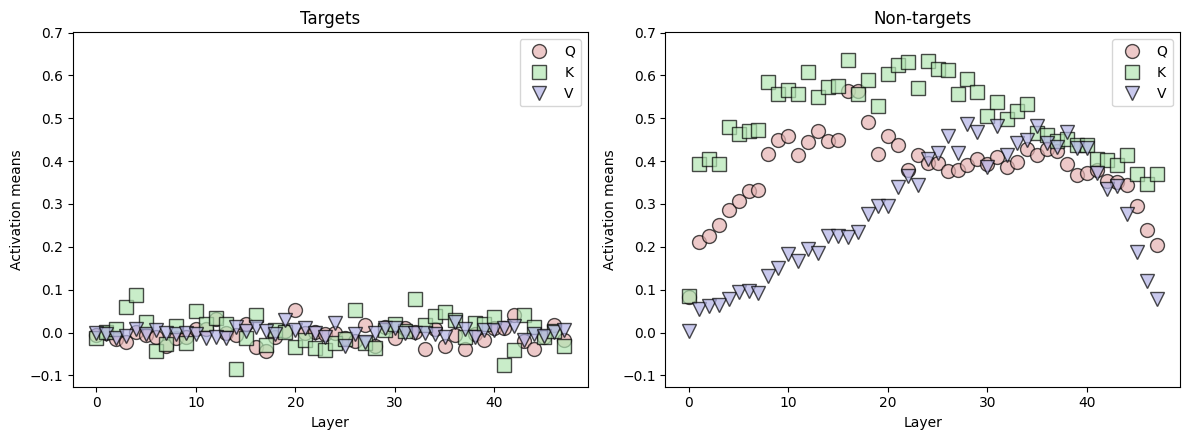

In [42]:
_,axs = plt.subplots(1,2,figsize=(12,4.5))

for i in range(2):
  axs[i].plot(all_mean[i,:,0],'ko',markerfacecolor=[.9,.7,.7,.7],markersize=10,label='Q')
  axs[i].plot(all_mean[i,:,1],'ks',markerfacecolor=[.7,.9,.7,.7],markersize=10,label='K')
  axs[i].plot(all_mean[i,:,2],'kv',markerfacecolor=[.7,.7,.9,.7],markersize=10,label='V')
  axs[i].set(xlabel='Layer',ylabel='Activation means',ylim=[all_mean.min()*1.5,all_mean.max()*1.1])
  axs[i].legend()

axs[0].set(title='Targets')
axs[1].set(title='Non-targets')

plt.tight_layout()
plt.show()

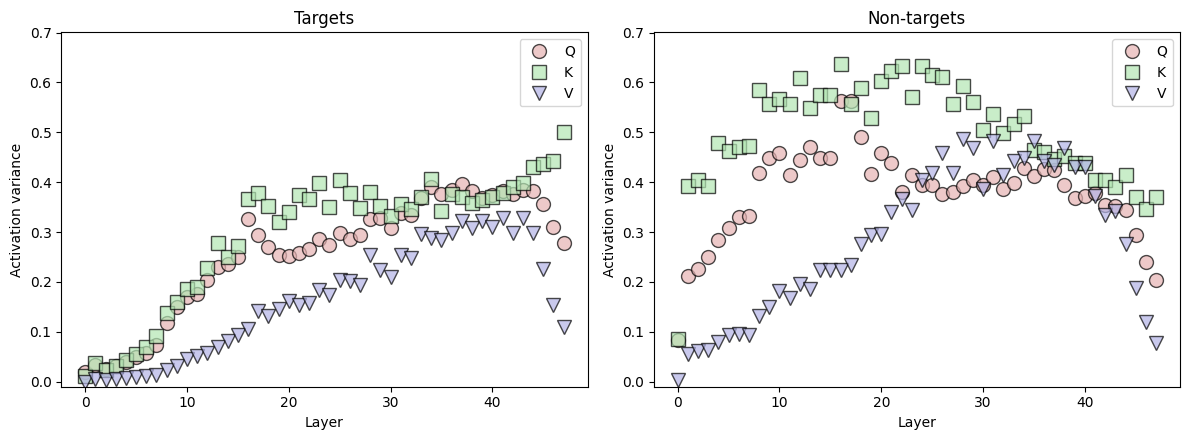

In [43]:
_,axs = plt.subplots(1,2,figsize=(12,4.5))

for i in range(2):
  axs[i].plot(all_vars[i,:,0],'ko',markerfacecolor=[.9,.7,.7,.7],markersize=10,label='Q')
  axs[i].plot(all_vars[i,:,1],'ks',markerfacecolor=[.7,.9,.7,.7],markersize=10,label='K')
  axs[i].plot(all_vars[i,:,2],'kv',markerfacecolor=[.7,.7,.9,.7],markersize=10,label='V')
  axs[i].set(xlabel='Layer',ylabel='Activation variance',ylim=[-.01,all_vars.max()*1.1])
  axs[i].legend()

axs[0].set(title='Targets')
axs[1].set(title='Non-targets')

plt.tight_layout()
plt.show()